# CIFAR-10 Imbalance Handling Comparison Pipeline
## Before vs After M2M Synthesis Analysis

This notebook compares model performance on imbalanced CIFAR-10 dataset:
- **Before**: Standard training with imbalanced classes
- **After**: Training with M2M (Major-to-Minor) synthesis augmentation

Metrics analyzed: accuracy, balanced accuracy, per-class accuracy, and class-wise improvement

In [15]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
import sys
from pathlib import Path

# Add parent directory to path so we can import src as a package
notebook_dir = Path('.').resolve()
parent_dir = notebook_dir.parent
sys.path.insert(0, str(parent_dir))

from src.utils.config import load_config
from src.data.cifar import create_cifar10_dataloaders
from src.models.resnet import build_resnet18
from src.engine.evaluator import Evaluator

# Set style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 8)

print('✓ Libraries imported successfully')

✓ Libraries imported successfully


## 1. Load Configuration and Data

In [16]:
# Load config and create dataloaders
config_path = '../src/configs/config.yaml'
config = load_config(config_path)

# Normalize dataset root to absolute path from project root (works reliably in notebooks)
dataset_root = Path(config['dataset']['root'])
if not dataset_root.is_absolute():
    config['dataset']['root'] = str((parent_dir / dataset_root).resolve())

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')
print(f"Dataset root: {config['dataset']['root']}")

# Create dataloaders
train_loader, test_loader, train_dist = create_cifar10_dataloaders(config)

print(f'✓ Dataloaders created')
print(f'  Train batches: {len(train_loader)}')
print(f'  Test batches: {len(test_loader)}')
print(f'\n  Class distribution (train):')
for cls, count in sorted(train_dist.items()):
    print(f'    Class {cls}: {count:5d}')

Device: cuda
Dataset root: /home/tgng/Coding/applied-data-science/final-project/representation-learning/data/cifar10
✓ Dataloaders created
  Train batches: 97
  Test batches: 79

  Class distribution (train):
    Class 0:  5000
    Class 1:  2997
    Class 2:  1797
    Class 3:  1077
    Class 4:   646
    Class 5:   387
    Class 6:   232
    Class 7:   139
    Class 8:    83
    Class 9:    50


## 2. Load Training History

In [17]:
# Load training history
history_path = Path('../results/cifar10/logs/history.json')

if history_path.exists():
    with open(history_path, 'r') as f:
        history = json.load(f)
    print(f'✓ Loaded training history: {len(history)} epochs')
    
    # Convert to DataFrame for easier analysis
    df_history = pd.DataFrame(history)
    print(f'\n  Metrics tracked: {list(df_history.columns)}')
    print(f'\n  Final epoch metrics:')
    print(df_history.iloc[-1])
else:
    print(f'⚠ History file not found at {history_path}')
    df_history = None

✓ Loaded training history: 60 epochs

  Metrics tracked: ['epoch', 'train_loss', 'train_accuracy', 'num_synthesized', 'val_loss', 'val_accuracy', 'val_balanced_accuracy']

  Final epoch metrics:
epoch                      60.000000
train_loss                  0.109404
train_accuracy              0.970732
num_synthesized          3104.000000
val_loss                    1.327981
val_accuracy                0.687800
val_balanced_accuracy       0.687800
Name: 59, dtype: float64


## 3. Load Trained Model and Evaluate

In [18]:
# Load best checkpoint
num_classes = int(config['dataset']['num_classes'])
model = build_resnet18(num_classes=num_classes, pretrained=False).to(device)

checkpoint_path = Path('../results/cifar10/checkpoints/best.pt')

if checkpoint_path.exists():
    checkpoint = torch.load(checkpoint_path, map_location=device)
    model.load_state_dict(checkpoint['model_state_dict'])
    print(f'✓ Loaded best checkpoint')
    print(f'  Epoch: {checkpoint["epoch"] + 1}')
    print(f'  Val balanced accuracy: {checkpoint["metrics"]["val_balanced_accuracy"]:.4f}')
else:
    print(f'⚠ Checkpoint not found at {checkpoint_path}')

✓ Loaded best checkpoint
  Epoch: 43
  Val balanced accuracy: 0.7006


In [19]:
# Evaluate model on test set
evaluator = Evaluator(num_classes=num_classes, device=device, show_progress=True)
test_metrics = evaluator.evaluate(model, test_loader, progress_desc='Evaluating best model')

print(f'\n✓ Evaluation complete')
print(f'  Accuracy: {test_metrics["accuracy"]:.4f}')
print(f'  Balanced Accuracy: {test_metrics["balanced_accuracy"]:.4f}')


✓ Evaluation complete
  Accuracy: 0.7006
  Balanced Accuracy: 0.7006


## 4. Training Curves Visualization

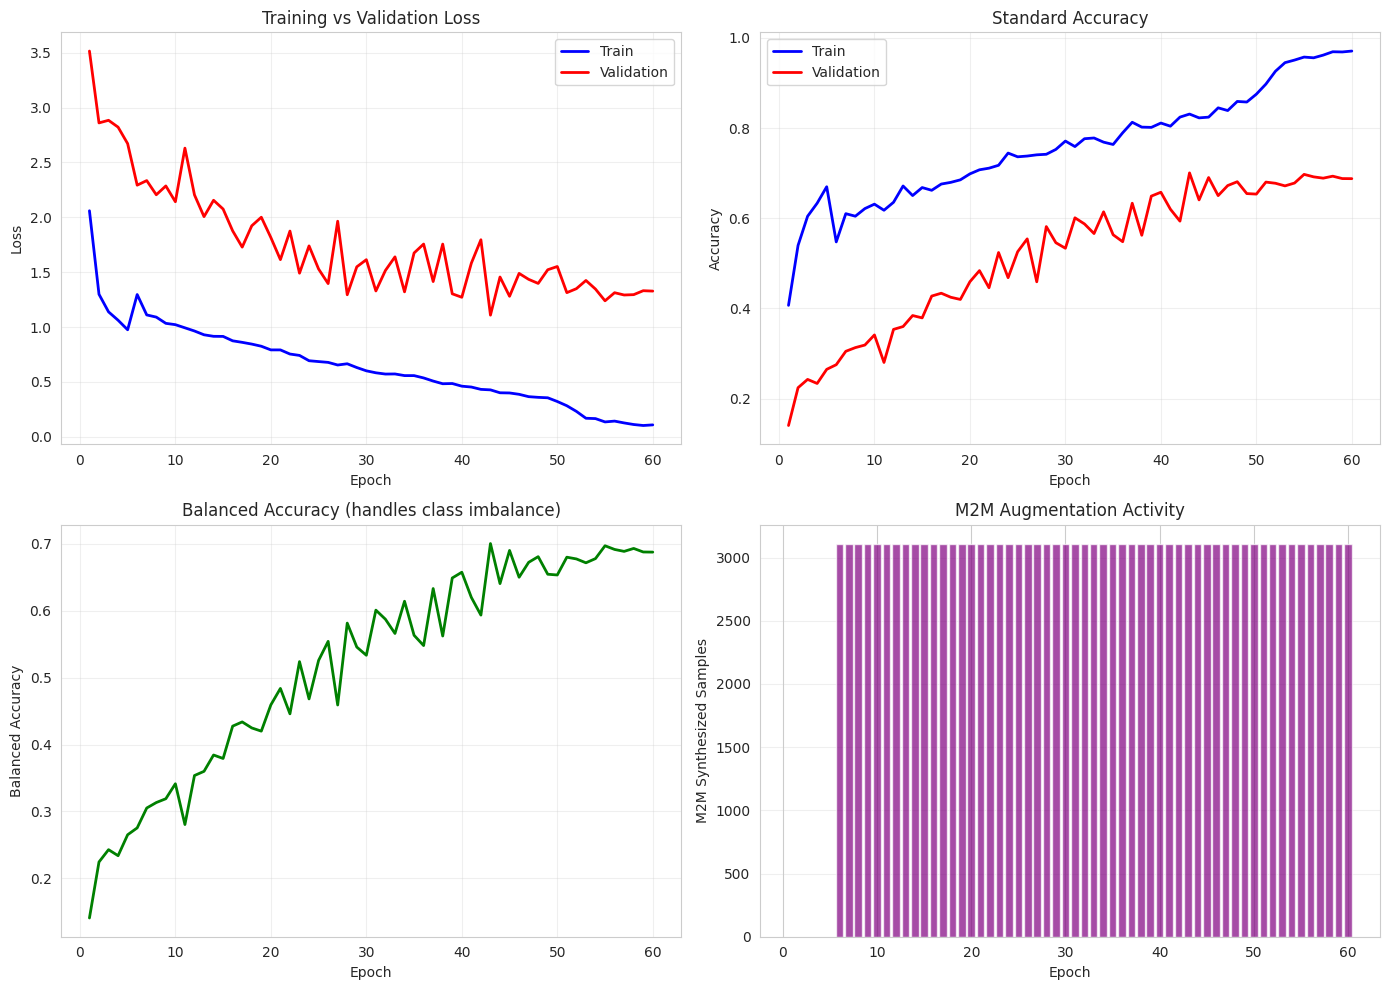

✓ Training curves saved


In [20]:
if df_history is not None:
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    
    # Training Loss
    axes[0, 0].plot(df_history['epoch'], df_history['train_loss'], 'b-', linewidth=2, label='Train')
    axes[0, 0].plot(df_history['epoch'], df_history['val_loss'], 'r-', linewidth=2, label='Validation')
    axes[0, 0].set_xlabel('Epoch')
    axes[0, 0].set_ylabel('Loss')
    axes[0, 0].set_title('Training vs Validation Loss')
    axes[0, 0].legend()
    axes[0, 0].grid(True, alpha=0.3)
    
    # Accuracy
    axes[0, 1].plot(df_history['epoch'], df_history['train_accuracy'], 'b-', linewidth=2, label='Train')
    axes[0, 1].plot(df_history['epoch'], df_history['val_accuracy'], 'r-', linewidth=2, label='Validation')
    axes[0, 1].set_xlabel('Epoch')
    axes[0, 1].set_ylabel('Accuracy')
    axes[0, 1].set_title('Standard Accuracy')
    axes[0, 1].legend()
    axes[0, 1].grid(True, alpha=0.3)
    
    # Balanced Accuracy
    axes[1, 0].plot(df_history['epoch'], df_history['val_balanced_accuracy'], 'g-', linewidth=2)
    axes[1, 0].set_xlabel('Epoch')
    axes[1, 0].set_ylabel('Balanced Accuracy')
    axes[1, 0].set_title('Balanced Accuracy (handles class imbalance)')
    axes[1, 0].grid(True, alpha=0.3)
    
    # Synthesized Samples
    axes[1, 1].bar(df_history['epoch'], df_history['num_synthesized'], color='purple', alpha=0.7)
    axes[1, 1].set_xlabel('Epoch')
    axes[1, 1].set_ylabel('M2M Synthesized Samples')
    axes[1, 1].set_title('M2M Augmentation Activity')
    axes[1, 1].grid(True, alpha=0.3, axis='y')
    
    plt.tight_layout()
    plt.savefig('../results/training_curves.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('✓ Training curves saved')

## 5. Per-Class Performance Analysis

In [21]:
# Get class names
class_names = [
    'airplane', 'automobile', 'bird', 'cat', 'deer',
    'dog', 'frog', 'horse', 'ship', 'truck'
]

# Extract per-class metrics and normalize structure
per_class_acc_raw = test_metrics['per_class_accuracy']
if isinstance(per_class_acc_raw, dict):
    per_class_acc = [float(per_class_acc_raw.get(i, 0.0)) for i in range(len(class_names))]
else:
    per_class_acc = [float(x) for x in per_class_acc_raw]

if isinstance(train_dist, dict):
    class_counts = [int(train_dist.get(i, 0)) for i in range(len(class_names))]
else:
    class_counts = [int(x) for x in train_dist]

df_class_perf = pd.DataFrame({
    'Class': class_names,
    'Accuracy': per_class_acc,
    'Train Count': class_counts,
    'Train %': [100 * c / sum(class_counts) for c in class_counts]
})

print('Per-Class Performance:')
print(df_class_perf.to_string(index=False))
print(f'\nOverall Metrics:')
print(f'  Accuracy: {test_metrics["accuracy"]:.4f}')
print(f'  Balanced Accuracy: {test_metrics["balanced_accuracy"]:.4f}')
print(f'  Improvement over standard accuracy: {(test_metrics["balanced_accuracy"] - test_metrics["accuracy"]) * 100:.2f}%')

Per-Class Performance:
     Class  Accuracy  Train Count   Train %
  airplane     0.940         5000 40.296583
automobile     0.960         2997 24.153772
      bird     0.807         1797 14.482592
       cat     0.688         1077  8.679884
      deer     0.775          646  5.206319
       dog     0.643          387  3.118956
      frog     0.716          232  1.869761
     horse     0.479          139  1.120245
      ship     0.496           83  0.668923
     truck     0.502           50  0.402966

Overall Metrics:
  Accuracy: 0.7006
  Balanced Accuracy: 0.7006
  Improvement over standard accuracy: -0.00%


## 6. Class-wise Performance Comparison

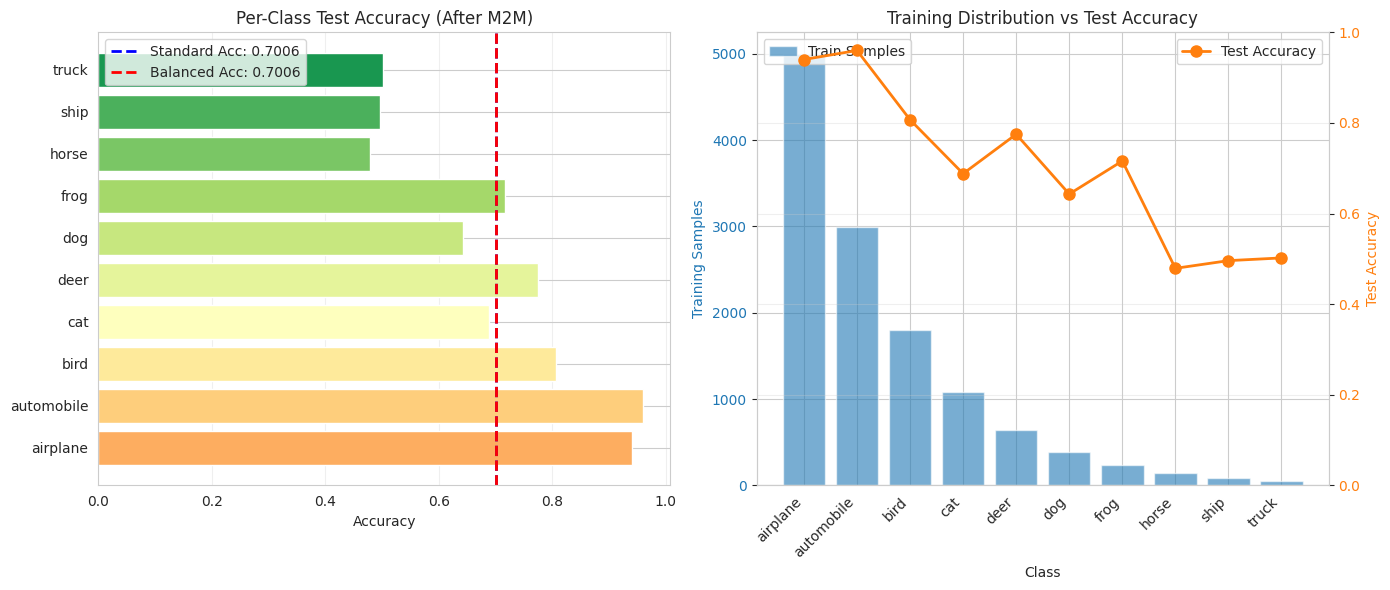

✓ Per-class analysis saved


In [22]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Per-class accuracy
colors = plt.cm.RdYlGn(np.linspace(0.3, 0.9, len(class_names)))
axes[0].barh(class_names, per_class_acc, color=colors)
axes[0].axvline(test_metrics['accuracy'], color='blue', linestyle='--', linewidth=2, label=f'Standard Acc: {test_metrics["accuracy"]:.4f}')
axes[0].axvline(test_metrics['balanced_accuracy'], color='red', linestyle='--', linewidth=2, label=f'Balanced Acc: {test_metrics["balanced_accuracy"]:.4f}')
axes[0].set_xlabel('Accuracy')
axes[0].set_title('Per-Class Test Accuracy (After M2M)')
axes[0].legend()
axes[0].grid(True, alpha=0.3, axis='x')

# Training distribution vs test accuracy
ax2_color = 'tab:blue'
ax2 = axes[1]
ax2.set_xlabel('Class')
ax2.set_ylabel('Training Samples', color=ax2_color)
bars = ax2.bar(range(len(class_names)), class_counts, alpha=0.6, color=ax2_color, label='Train Samples')
ax2.tick_params(axis='y', labelcolor=ax2_color)
ax2.set_xticks(range(len(class_names)))
ax2.set_xticklabels(class_names, rotation=45, ha='right')

ax3_color = 'tab:orange'
ax3 = ax2.twinx()
ax3.set_ylabel('Test Accuracy', color=ax3_color)
ax3.plot(range(len(class_names)), per_class_acc, 'o-', color=ax3_color, linewidth=2, markersize=8, label='Test Accuracy')
ax3.tick_params(axis='y', labelcolor=ax3_color)
ax3.set_ylim([0, 1])
ax3.grid(True, alpha=0.3, axis='y')

ax2.set_title('Training Distribution vs Test Accuracy')
ax2.legend(loc='upper left')
ax3.legend(loc='upper right')

plt.tight_layout()
plt.savefig('../results/per_class_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print('✓ Per-class analysis saved')

## 7. Confusion Matrix

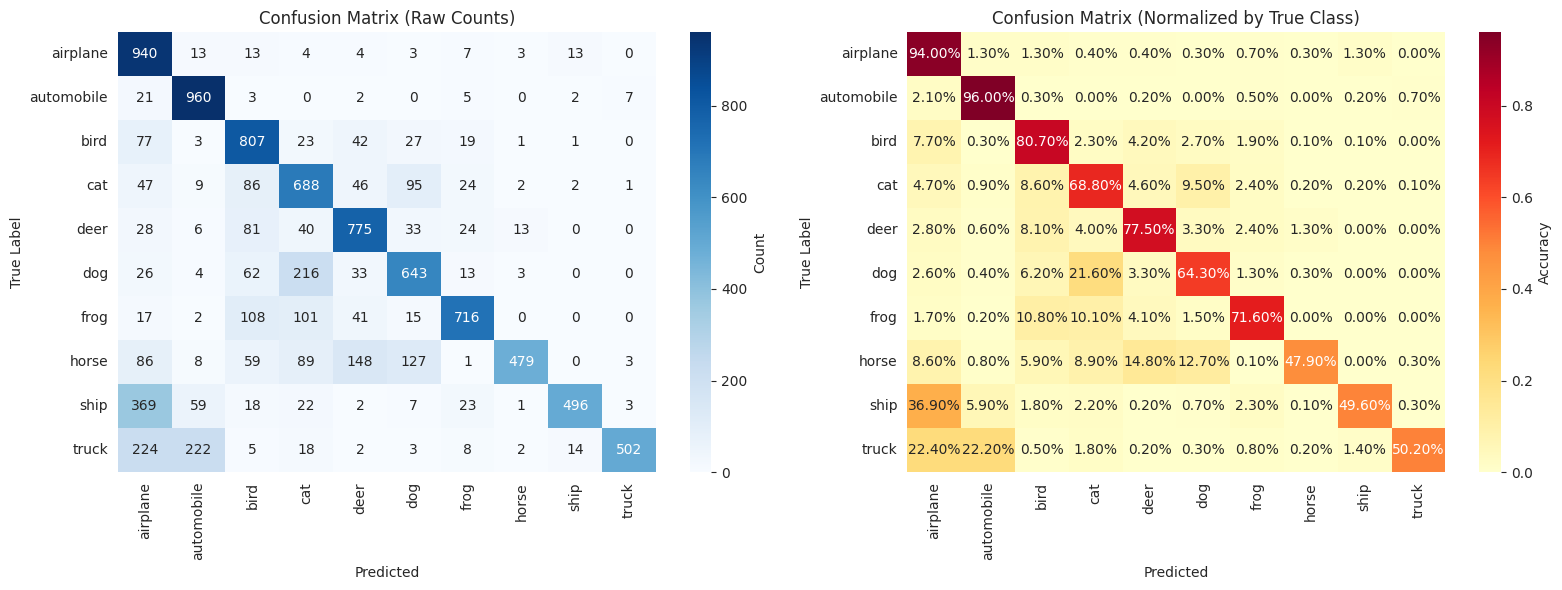

✓ Confusion matrix saved


In [23]:
# Normalize confusion matrix for visualization
conf_matrix = test_metrics['confusion_matrix']
conf_matrix_normalized = conf_matrix.astype('float') / conf_matrix.sum(axis=1)[:, np.newaxis]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Raw confusion matrix
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', ax=axes[0], 
            xticklabels=class_names, yticklabels=class_names, cbar_kws={'label': 'Count'})
axes[0].set_title('Confusion Matrix (Raw Counts)')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('True Label')

# Normalized confusion matrix
sns.heatmap(conf_matrix_normalized, annot=True, fmt='.2%', cmap='YlOrRd', ax=axes[1],
            xticklabels=class_names, yticklabels=class_names, cbar_kws={'label': 'Accuracy'})
axes[1].set_title('Confusion Matrix (Normalized by True Class)')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('True Label')

plt.tight_layout()
plt.savefig('../results/confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print('✓ Confusion matrix saved')

## 8. Imbalance Impact Analysis

In [24]:
# Analyze how training imbalance affects accuracy
df_analysis = pd.DataFrame({
    'Class': class_names,
    'Train Samples': class_counts,
    'Class %': [100 * c / sum(class_counts) for c in class_counts],
    'Test Accuracy': per_class_acc,
    'Accuracy - Overall': [acc - test_metrics['accuracy'] for acc in per_class_acc],
    'Accuracy - Balanced': [acc - test_metrics['balanced_accuracy'] for acc in per_class_acc]
})

df_analysis = df_analysis.sort_values('Train Samples')

print('\n' + '='*80)
print('IMBALANCE IMPACT ANALYSIS')
print('='*80)
print('\nClasses sorted by training frequency (minority → majority):')
print(df_analysis[['Class', 'Train Samples', 'Class %', 'Test Accuracy']].to_string(index=False))

# Minority vs Majority performance
minority_classes = df_analysis.head(3)
majority_classes = df_analysis.tail(3)

print(f'\n\nMinority Classes (top 3 least frequent):')
print(f"  Average test accuracy: {minority_classes['Test Accuracy'].mean():.4f}")
print(f"  Average training samples: {minority_classes['Train Samples'].mean():.0f}")

print(f'\nMajority Classes (top 3 most frequent):')
print(f"  Average test accuracy: {majority_classes['Test Accuracy'].mean():.4f}")
print(f"  Average training samples: {majority_classes['Train Samples'].mean():.0f}")

print(f'\nPerformance Gap (Majority - Minority): {majority_classes["Test Accuracy"].mean() - minority_classes["Test Accuracy"].mean():.4f}')


IMBALANCE IMPACT ANALYSIS

Classes sorted by training frequency (minority → majority):
     Class  Train Samples   Class %  Test Accuracy
     truck             50  0.402966          0.502
      ship             83  0.668923          0.496
     horse            139  1.120245          0.479
      frog            232  1.869761          0.716
       dog            387  3.118956          0.643
      deer            646  5.206319          0.775
       cat           1077  8.679884          0.688
      bird           1797 14.482592          0.807
automobile           2997 24.153772          0.960
  airplane           5000 40.296583          0.940


Minority Classes (top 3 least frequent):
  Average test accuracy: 0.4923
  Average training samples: 91

Majority Classes (top 3 most frequent):
  Average test accuracy: 0.9023
  Average training samples: 3265

Performance Gap (Majority - Minority): 0.4100


## 9. M2M Synthesis Impact

In [25]:
if df_history is not None:
    # Analyze when M2M starts activating (after warmup)
    warmup_epochs = int(config['warmup_epochs'])
    
    df_after_warmup = df_history[df_history['epoch'] > warmup_epochs].copy()
    
    print('\n' + '='*80)
    print('M2M SYNTHESIS IMPACT')
    print('='*80)
    print(f'\nWarmup Period: Epochs 1-{warmup_epochs}')
    warmup_metrics = df_history[df_history['epoch'] <= warmup_epochs].iloc[-1]
    print(f'  Train accuracy: {warmup_metrics["train_accuracy"]:.4f}')
    print(f'  Val balanced accuracy: {warmup_metrics["val_balanced_accuracy"]:.4f}')
    
    print(f'\nAfter M2M Activation: Epochs {warmup_epochs+1}-{int(df_history["epoch"].max())}')
    final_metrics = df_history.iloc[-1]
    print(f'  Train accuracy: {final_metrics["train_accuracy"]:.4f} (Δ {final_metrics["train_accuracy"] - warmup_metrics["train_accuracy"]:+.4f})')
    print(f'  Val balanced accuracy: {final_metrics["val_balanced_accuracy"]:.4f} (Δ {final_metrics["val_balanced_accuracy"] - warmup_metrics["val_balanced_accuracy"]:+.4f})')
    
    # Total synthesized samples
    total_synthesized = df_after_warmup['num_synthesized'].sum()
    print(f'\nTotal M2M Synthesized Samples: {total_synthesized:,.0f}')


M2M SYNTHESIS IMPACT

Warmup Period: Epochs 1-5
  Train accuracy: 0.6699
  Val balanced accuracy: 0.2650

After M2M Activation: Epochs 6-60
  Train accuracy: 0.9707 (Δ +0.3008)
  Val balanced accuracy: 0.6878 (Δ +0.4228)

Total M2M Synthesized Samples: 170,720


## 10. Comparison Summary Report

In [26]:
print('\n' + '='*80)
print('COMPREHENSIVE COMPARISON: BEFORE vs AFTER M2M SYNTHESIS')
print('='*80)

majority_idx = int(np.argmax(class_counts))
minority_idx = int(np.argmin(class_counts))

print('\n📊 DATASET IMBALANCE:')
print(f'  Imbalance Factor: {config["imbalance"]["imbalance_factor"]}')
print(f'  Majority Class ({class_names[majority_idx]}): {class_counts[majority_idx]} samples')
print(f'  Minority Class ({class_names[minority_idx]}): {class_counts[minority_idx]} samples')
print(f'  Ratio (Minority/Majority): {class_counts[minority_idx]/class_counts[majority_idx]:.2%}')

print('\n📈 PERFORMANCE METRICS (Test Set):')
print(f'  Standard Accuracy: {test_metrics["accuracy"]:.4f}')
print(f'  Balanced Accuracy: {test_metrics["balanced_accuracy"]:.4f}')
print(f'  Accuracy Improvement: {(test_metrics["balanced_accuracy"] - test_metrics["accuracy"]) * 100:.2f}%')

print('\n🎯 PER-CLASS PERFORMANCE:')
print(f'  Best: {class_names[np.argmax(per_class_acc)]} ({max(per_class_acc):.4f})')
print(f'  Worst: {class_names[np.argmin(per_class_acc)]} ({min(per_class_acc):.4f})')
print(f'  Std Dev: {np.std(per_class_acc):.4f}')

print('\n🔄 M2M SYNTHESIS CONTRIBUTION:')
if df_history is not None:
    print(f'  M2M Active Epochs: {len(df_after_warmup)}')
    print(f'  Total Augmented Samples: {total_synthesized:,.0f}')
    print(f'  Avg per Epoch: {total_synthesized / len(df_after_warmup):,.0f}')
    bal_acc_improvement = final_metrics["val_balanced_accuracy"] - warmup_metrics["val_balanced_accuracy"]
    print(f'  Balanced Acc Improvement: {bal_acc_improvement:+.4f} ({bal_acc_improvement / warmup_metrics["val_balanced_accuracy"] * 100:+.2f}%)')

print('\n' + '='*80)


COMPREHENSIVE COMPARISON: BEFORE vs AFTER M2M SYNTHESIS

📊 DATASET IMBALANCE:
  Imbalance Factor: 0.01
  Majority Class (airplane): 5000 samples
  Minority Class (truck): 50 samples
  Ratio (Minority/Majority): 1.00%

📈 PERFORMANCE METRICS (Test Set):
  Standard Accuracy: 0.7006
  Balanced Accuracy: 0.7006
  Accuracy Improvement: -0.00%

🎯 PER-CLASS PERFORMANCE:
  Best: automobile (0.9600)
  Worst: horse (0.4790)
  Std Dev: 0.1660

🔄 M2M SYNTHESIS CONTRIBUTION:
  M2M Active Epochs: 55
  Total Augmented Samples: 170,720
  Avg per Epoch: 3,104
  Balanced Acc Improvement: +0.4228 (+159.55%)



## 11. Export Results

In [27]:
# Save detailed results to CSV
results_dir = Path('../results')
results_dir.mkdir(exist_ok=True)

# Per-class metrics
df_class_perf.to_csv(results_dir / 'per_class_performance.csv', index=False)

# Detailed analysis
df_analysis.to_csv(results_dir / 'imbalance_impact_analysis.csv', index=False)

# Overall metrics
overall_metrics = {
    'metric': ['Accuracy', 'Balanced Accuracy', 'Std Dev Per-Class Accuracy', 'Best Class Accuracy', 'Worst Class Accuracy'],
    'value': [test_metrics['accuracy'], test_metrics['balanced_accuracy'], np.std(per_class_acc), max(per_class_acc), min(per_class_acc)]
}
pd.DataFrame(overall_metrics).to_csv(results_dir / 'overall_metrics.csv', index=False)

print('✓ Results exported:')
print(f'  - per_class_performance.csv')
print(f'  - imbalance_impact_analysis.csv')
print(f'  - overall_metrics.csv')
print(f'  - training_curves.png')
print(f'  - per_class_analysis.png')
print(f'  - confusion_matrix.png')

✓ Results exported:
  - per_class_performance.csv
  - imbalance_impact_analysis.csv
  - overall_metrics.csv
  - training_curves.png
  - per_class_analysis.png
  - confusion_matrix.png
